In [22]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('transactions_kz (1).csv')

In [12]:
df.head()

,transaction_id,client_id,bank,sender_account,receiver_account,amount_kzt,category,city,device_type,transaction_date,status,is_fraud,fraud_reason,description
0,8ad94414-9f09-4a1c-8826-3fd78ecdb2fb,710922412037,Kaspi Bank,KZ905123496327070512,KZ812540996263964914,32161,Онлайн-покупки,Усть-Каменогорск,ussd,2025-11-21 10:28:00,pending,0,NaN,Онлайн-покупки - Усть-Каменогорск
1,512d1f8f-d13a-4efe-a104-aa6efa931a8d,670514467078,ForteBank,KZ947579493143681123,KZ181707027985801243,110982,Развлечения,Семей,pos_terminal,2025-08-17 21:06:00,completed,0,NaN,Развлечения - Семей
2,d8c5c71f-6fb0-4012-8629-773e80f3611d,681120467573,Bank CenterCredit,KZ937541341245977941,KZ916253238273502243,34069,Образование,Атырау,pos_terminal,2026-02-05 05:35:00,completed,0,NaN,Образование - Атырау
3,c29374b1-5ff9-4a6f-a5a8-e9a60b9aadda,681012343695,Нурбанк,KZ915003396005377560,KZ249044043637392438,11805,Транспорт,Атырау,web,2026-02-23 05:48:00,completed,0,NaN,Транспорт - Атырау
4,b33eb7a2-6de0-410f-8b8e-4fb056994400,910227441329,ATF Bank,KZ879381067568250642,KZ824360584515682321,6955,Образование,Павлодар,atm,2025-09-02 14:17:00,completed,0,NaN,Образование - Павлодар


In [13]:
df.describe()

,client_id,amount_kzt,is_fraud
count,5.000000e+03,5.000000e+03,5000.000000
mean,7.907385e+11,2.061874e+05,0.050600
std,1.163676e+11,8.367052e+05,0.219201
min,6.001033e+11,1.140000e+02,0.000000
25%,6.903025e+11,1.449175e+04,0.000000
50%,7.903024e+11,7.958300e+04,0.000000
75%,8.912214e+11,1.539052e+05,0.000000
max,9.909205e+11,9.987096e+06,1.000000


In [14]:
print("Размер датасета:", df.shape)
print("\nКолонки:")
print(df.columns)

Размер датасета: (5000, 14)

Колонки:
Index(['transaction_id', 'client_id', 'bank', 'sender_account',
       'receiver_account', 'amount_kzt', 'category', 'city', 'device_type',
       'transaction_date', 'status', 'is_fraud', 'fraud_reason',
       'description'],
      dtype='object')


In [15]:
print("\nТипы данных:")
print(df.info())


Типы данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    5000 non-null   object
 1   client_id         5000 non-null   int64 
 2   bank              5000 non-null   object
 3   sender_account    5000 non-null   object
 4   receiver_account  5000 non-null   object
 5   amount_kzt        5000 non-null   int64 
 6   category          5000 non-null   object
 7   city              5000 non-null   object
 8   device_type       5000 non-null   object
 9   transaction_date  5000 non-null   object
 10  status            5000 non-null   object
 11  is_fraud          5000 non-null   int64 
 12  fraud_reason      253 non-null    object
 13  description       5000 non-null   object
dtypes: int64(3), object(11)
memory usage: 547.0+ KB
None


In [16]:
print("\nПропущенные значения:")
print(df.isnull().sum())


Пропущенные значения:
transaction_id         0
client_id              0
bank                   0
sender_account         0
receiver_account       0
amount_kzt             0
category               0
city                   0
device_type            0
transaction_date       0
status                 0
is_fraud               0
fraud_reason        4747
description            0
dtype: int64


In [18]:
duplicates = df.duplicated().sum()
print("\nКоличество дубликатов:", duplicates)


Количество дубликатов: 0


In [20]:
fraud_counts = df["is_fraud"].value_counts()
print("\nРаспределение fraud:")
print(fraud_counts)


Распределение fraud:
is_fraud
0    4747
1     253
Name: count, dtype: int64


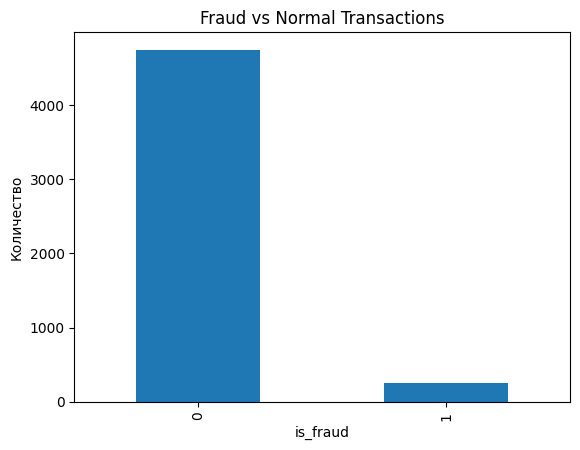

In [23]:
plt.figure()
fraud_counts.plot(kind="bar")
plt.title("Fraud vs Normal Transactions")
plt.xlabel("is_fraud")
plt.ylabel("Количество")
plt.show()

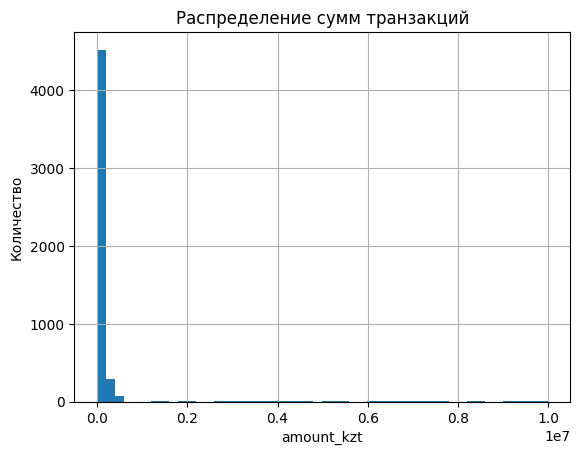

In [24]:
plt.figure()
df["amount_kzt"].hist(bins=50)
plt.title("Распределение сумм транзакций")
plt.xlabel("amount_kzt")
plt.ylabel("Количество")
plt.show()

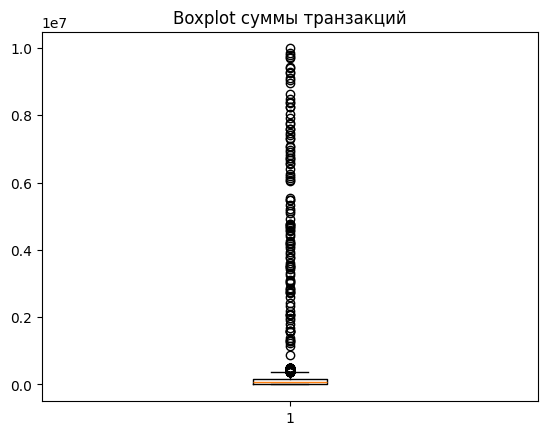

In [25]:
plt.figure()
plt.boxplot(df["amount_kzt"])
plt.title("Boxplot суммы транзакций")
plt.show()


Fraud rate по банкам:
bank
ATF Bank              0.073501
Bank CenterCredit     0.040000
ForteBank             0.050584
Halyk Bank            0.046843
Jusan Bank            0.051760
Kaspi Bank            0.061630
RBK Bank              0.048218
Евразийский Банк      0.037736
Нурбанк               0.040254
Сбербанк Казахстан    0.054581
Name: is_fraud, dtype: float64


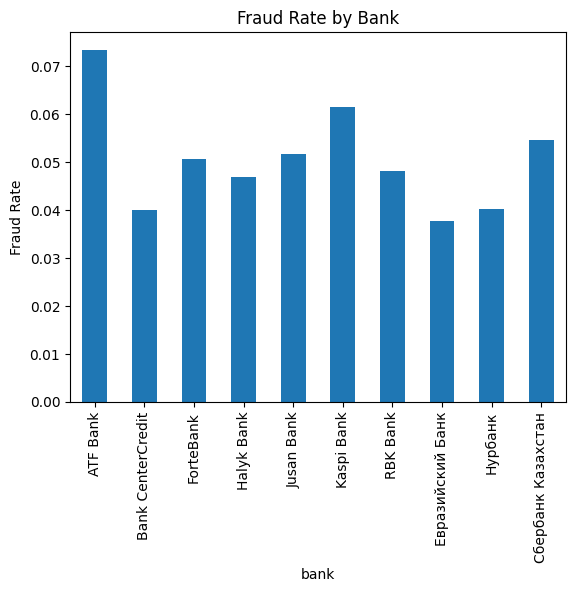

In [27]:
fraud_by_bank = df.groupby("bank")["is_fraud"].mean()
print("\nFraud rate по банкам:")
print(fraud_by_bank)

plt.figure()
fraud_by_bank.plot(kind="bar")
plt.title("Fraud Rate by Bank")
plt.ylabel("Fraud Rate")
plt.show()



Fraud rate по устройствам:
device_type
atm             0.049578
mobile_app      0.055221
pos_terminal    0.040942
ussd            0.057229
web             0.049861
Name: is_fraud, dtype: float64


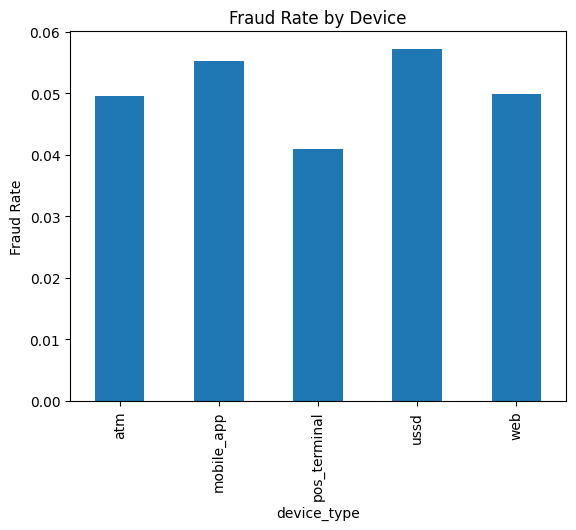

In [28]:
fraud_by_device = df.groupby("device_type")["is_fraud"].mean()
print("\nFraud rate по устройствам:")
print(fraud_by_device)

plt.figure()
fraud_by_device.plot(kind="bar")
plt.title("Fraud Rate by Device")
plt.ylabel("Fraud Rate")
plt.show()

In [29]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["hour"] = df["transaction_date"].dt.hour

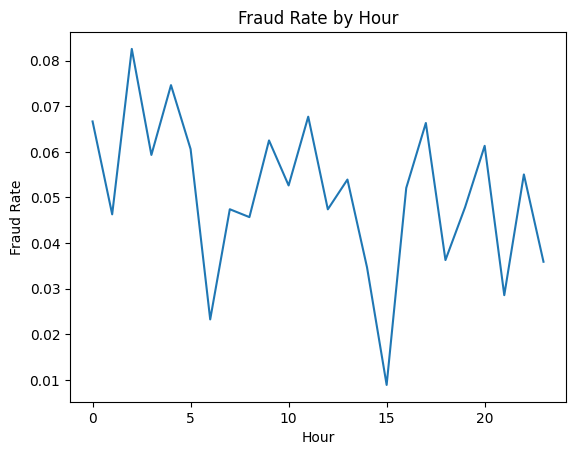

In [30]:
fraud_by_hour = df.groupby("hour")["is_fraud"].mean()

plt.figure()
fraud_by_hour.plot()
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.show()

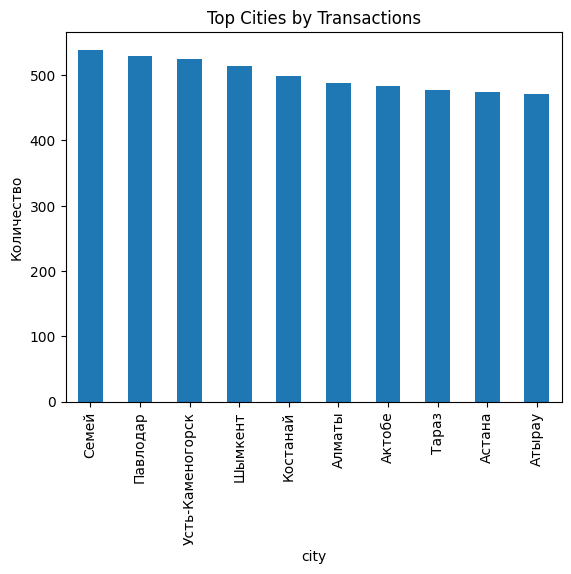

In [31]:
top_cities = df["city"].value_counts().head(10)

plt.figure()
top_cities.plot(kind="bar")
plt.title("Top Cities by Transactions")
plt.ylabel("Количество")
plt.show()